# EDA 05.01 — Dataset Overview and Coverage

All calculations use `master_dataset_clean.parquet`. The source dataset is not modified.

In [1]:
# Import libraries
from pathlib import Path
import sys
from IPython.display import Image, display

In [2]:
# define the root directory of the project
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'eda.yaml'

CONFIG_PATH

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/Codigo/ontario-electricity-peak-risk/configs/eda.yaml')

In [3]:
# Import module to manage the EDA process
from src.ontario_peak_risk.eda.common import (
    load_eda_config,
    prepare_output_directories,
    load_clean_dataset,
)

In [4]:
# Config EDA process and Load the dataset
CONFIG, _ = load_eda_config(CONFIG_PATH)
REPORTS_DIR, FIGURES_DIR, DOCS_DIR = prepare_output_directories(CONFIG, PROJECT_ROOT)
dataset = load_clean_dataset(CONFIG, PROJECT_ROOT)
TARGET = CONFIG['columns']['target']

dataset.shape

(262944, 66)

In [5]:
# import the function to run the overview of the dataset
from src.ontario_peak_risk.eda.overview import run_overview

In [6]:
# Generate the overview of the dataset and save the results in the output directories
results = run_overview(dataset, REPORTS_DIR, FIGURES_DIR, DOCS_DIR)


In [8]:
# View overview
results['overview']

,rows,columns,memory_mb,numeric_columns,categorical_columns,minimum_timestamp,maximum_timestamp,unique_fsas
0,262944,66,70.977,54,8,2021-01-01,2025-12-31 23:00:00,6


In [9]:
# View details of columns
results["dtypes"]

,column,dtype,non_null_count,missing_pct,unique_count
0,fsa,category,262944,0.000000,6
1,timestamp,datetime64[ns],262944,0.000000,43824
2,total_consumption_kwh,float64,262944,0.000000,157393
3,reported_premise_count,Int64,262944,0.000000,1269
4,source_segment_count,Int8,262944,0.000000,6
...,...,...,...,...,...
61,Visibility (km),float64,131451,50.007986,30
62,Stn Press (kPa),float64,262803,0.053624,664
63,Hmdx,float64,46290,82.395491,22
64,Wind Chill,float64,26346,89.980376,34


In [10]:
# View Coverage
results["coverage"]

,fsa,rows,unique_hours,minimum_timestamp,maximum_timestamp,expected_continuous_hours,missing_hour_count,duplicate_timestamp_rows,non_one_hour_gaps,first_missing_examples
0,L4T,43824,43824,2021-01-01,2025-12-31 23:00:00,43824,0,0,0,
1,M5R,43824,43824,2021-01-01,2025-12-31 23:00:00,43824,0,0,0,
2,M5S,43824,43824,2021-01-01,2025-12-31 23:00:00,43824,0,0,0,
3,M6G,43824,43824,2021-01-01,2025-12-31 23:00:00,43824,0,0,0,
4,M9R,43824,43824,2021-01-01,2025-12-31 23:00:00,43824,0,0,0,
5,M9W,43824,43824,2021-01-01,2025-12-31 23:00:00,43824,0,0,0,


In [11]:
# View missingness
results["missingness"].query("missing_pct > 0")

,column,missing_count,missing_pct
0,Wind Chill,236598,89.980376
1,Hmdx,216654,82.395491
2,Weather,206784,78.641840
3,Wind Dir (10s deg),133668,50.835159
4,Precip. Amount (mm),131595,50.046778
5,Visibility (km),131493,50.007986
6,Wind Spd (km/h),131490,50.006846
7,Dew Point Temp (°C),144,0.054765
8,Rel Hum (%),144,0.054765
9,Temp (°C),141,0.053624


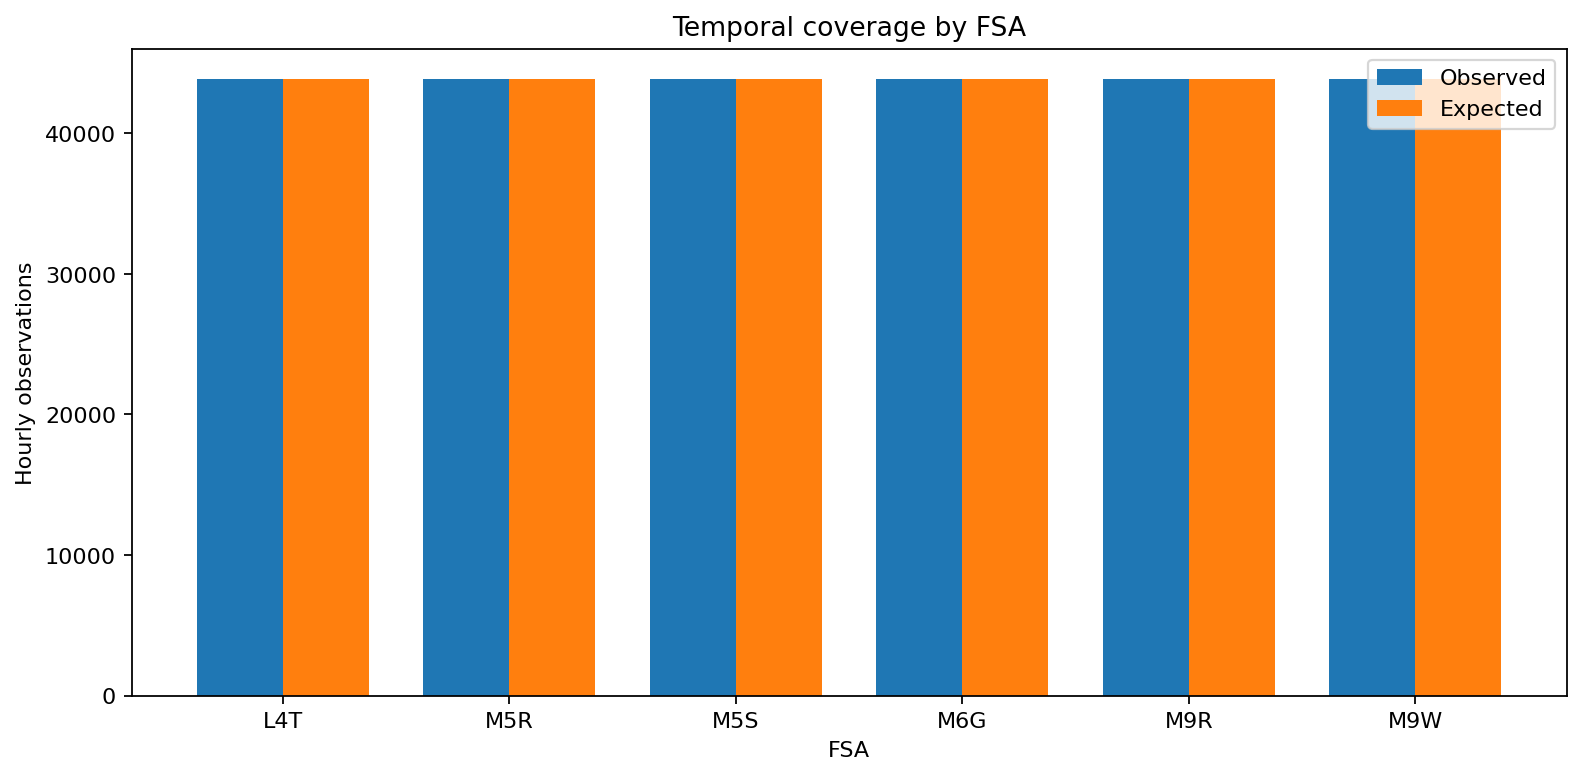

In [12]:
# View temporal coverage
display(
    Image(
        filename=FIGURES_DIR / "05_01_temporal_coverage_by_fsa.png"
    )
)



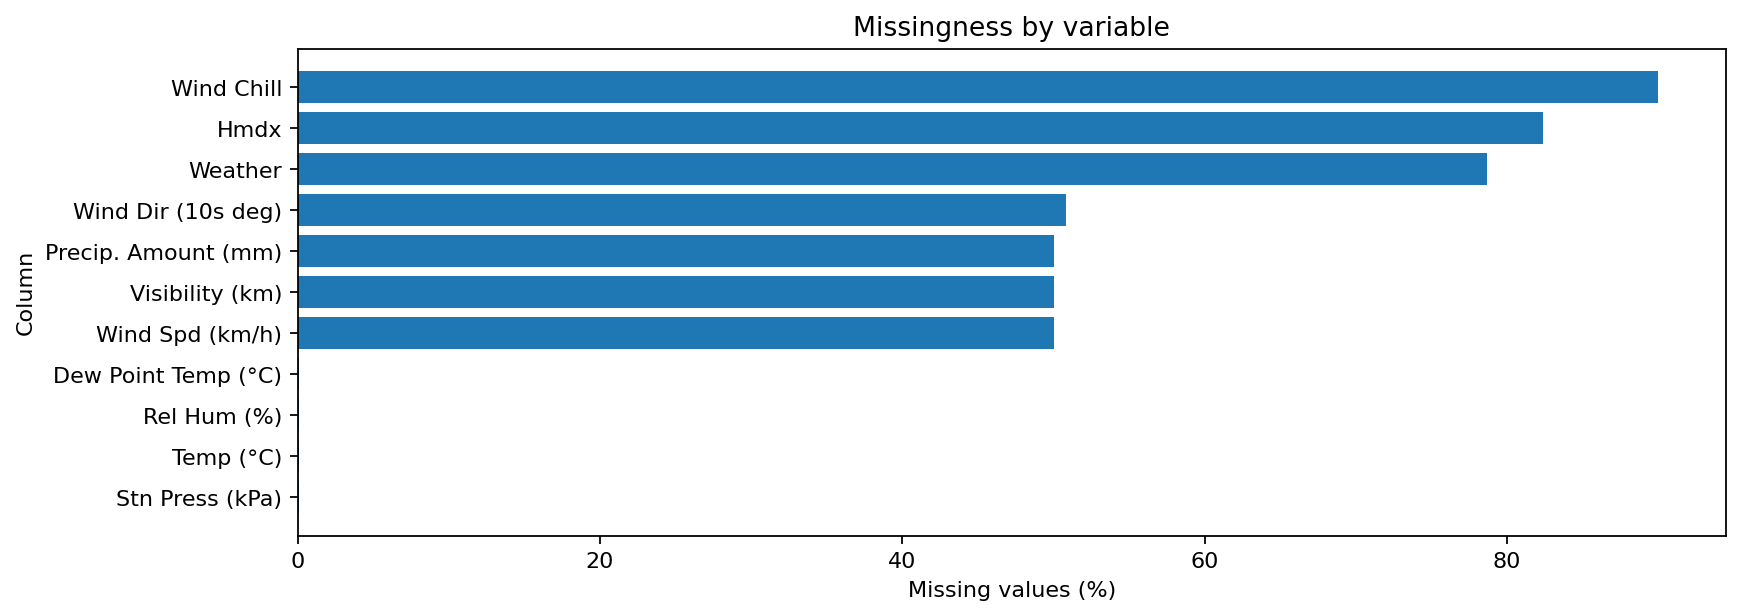

In [13]:
# View missingness
display(
    Image(
        filename=FIGURES_DIR / "05_01_missingness_by_variable.png"
    )
)

## Summary
Review the generated CSV tables, figures, and Markdown section report.

Review: 
- Report under `docs/eda/05_01_Dataset_Overview_and_Coverage.md`.
- CSV reports under `reports/eda/`.